In [1]:
import re
import os

In [ ]:
regex = re.compile(".*\.wav")
wav_files = [1 if regex.match(f) is not None else 0 for _, _, files_list in os.walk("../data/dataset") for f in files_list]
sum(wav_files)

64727

In [22]:
import librosa
from librosa.feature import melspectrogram
import torch
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
import torchvision.transforms as transforms

(16000,) 16000
(128, 126)


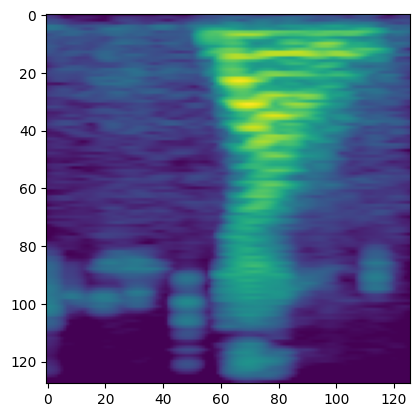

In [ ]:
X_np, sr = librosa.load("../data/dataset/train/down/down_0a7c2a8d_nohash_0.wav", sr=None)
print(X_np.shape, sr)
X = torch.tensor(X_np)
mel_spec = melspectrogram(y=X_np, sr=sr, n_fft=2048, n_mels=128, hop_length=128)
mel_spec = librosa.power_to_db(mel_spec)
# mel_specgram = mel_spec(torch.nn.functional.normalize(X, p=2, dim=0))
print(mel_spec.shape)
plt.imshow(mel_spec)

(13654,) 16000
torch.Size([128, 107])
torch.Size([128, 107])
torch.Size([128, 107])


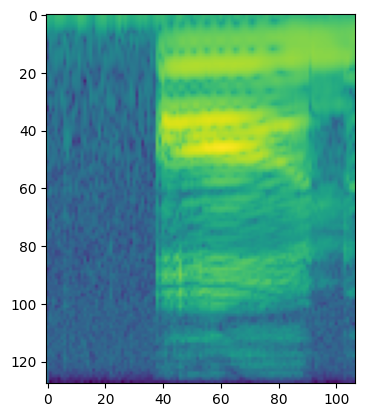

In [29]:
X_np, sr = librosa.load("../data/dataset/train/on/on_0a9f9af7_nohash_0.wav", sr=None)
print(X_np.shape, sr)
X = torch.tensor(X_np)
mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=2048, n_mels=128, win_length=256)
mel_specgram = mel_spec(torch.nn.functional.normalize(X, p=2, dim=0))
print(mel_specgram.shape)
mel_specgram: torch.Tensor = T.AmplitudeToDB()(mel_specgram)
print(mel_specgram.shape)
# mel_specgram = transforms.Resize((128, 128))(mel_specgram.unsqueeze(0))
print(mel_specgram.shape)
plt.imshow(mel_specgram)

In [10]:
mel_specgram.shape


torch.Size([128, 81])

(16000,) 16000


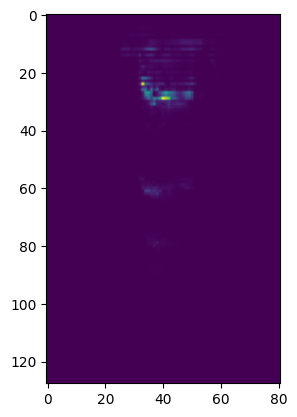

In [77]:
X_np, sr = librosa.load("../data/dataset/train/bed/fffcabd1_nohash_0.wav", sr=None)
print(X_np.shape, sr)
X = torch.tensor(X_np)
mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=400, n_mels=128)
mel_specgram = mel_spec(torch.nn.functional.normalize(X, p=2, dim=0))
plt.imshow(mel_specgram)

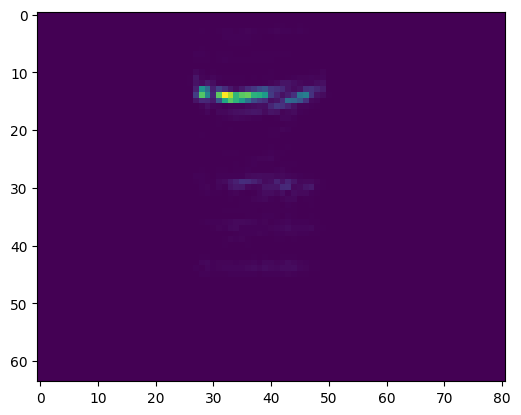

In [46]:

mel_specgram = mel_spec(X)
plt.imshow(mel_specgram)

In [47]:
torch.mean(X), torch.std(X)

(tensor(-0.0013), tensor(0.2810))

In [50]:
X_norm = torch.nn.functional.normalize(X, p=2, dim=0)
torch.mean(X_norm), torch.std(X_norm)**2

(tensor(-3.7485e-05), tensor(6.2502e-05))

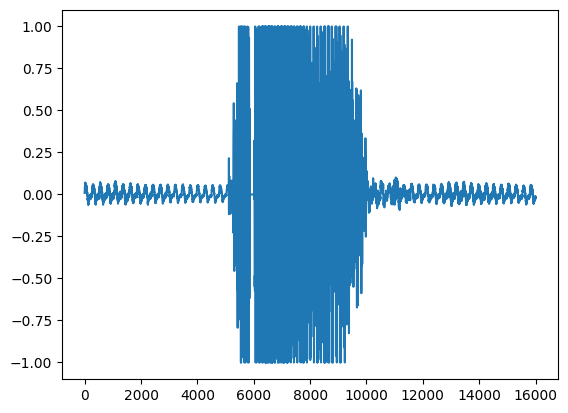

In [56]:
plt.plot(X_np)

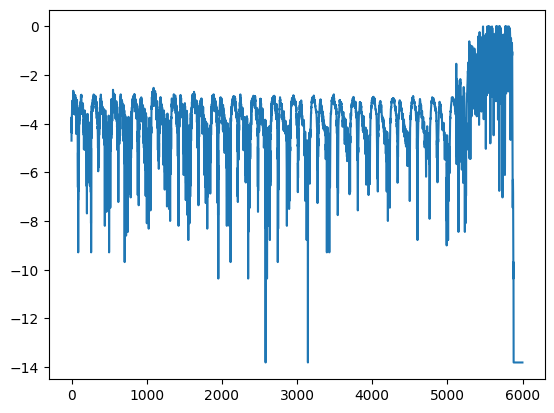

In [70]:
plt.plot(torch.log(torch.abs(X[:6000]) + 1e-6))

In [62]:
X_np[5000:5500]

array([-5.37109375e-03, -8.08715820e-03, -6.92749023e-03, -9.76562500e-04,
       -4.57763672e-03, -2.44140625e-03,  3.41796875e-03,  1.52587891e-04,
       -3.26538086e-03, -1.34277344e-03, -1.52587891e-04, -3.17382812e-03,
       -2.96020508e-03, -4.27246094e-03, -3.41796875e-03,  1.25122070e-03,
       -2.50244141e-03, -3.57055664e-03, -7.62939453e-04, -3.08227539e-03,
       -6.16455078e-03, -6.74438477e-03, -7.17163086e-03, -4.88281250e-03,
       -5.61523438e-03, -7.17163086e-03, -4.51660156e-03, -4.73022461e-03,
       -2.38037109e-03,  2.71606445e-03,  4.18090820e-03,  4.27246094e-03,
        7.84301758e-03,  8.91113281e-03,  1.01013184e-02,  1.57165527e-02,
        1.75476074e-02,  2.03857422e-02,  2.38647461e-02,  2.26440430e-02,
        2.38342285e-02,  2.68249512e-02,  2.85034180e-02,  3.08837891e-02,
        3.01818848e-02,  2.98461914e-02,  3.33251953e-02,  3.50952148e-02,
        3.57971191e-02,  3.68347168e-02,  3.84216309e-02,  4.04663086e-02,
        4.26330566e-02,  

In [ ]:

mel_specgram.shape

torch.Size([128, 81])

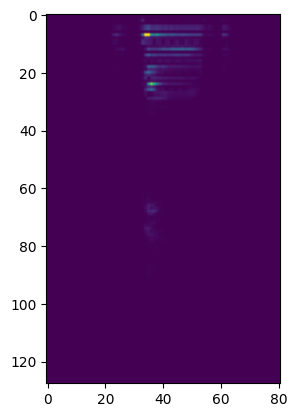

In [11]:
X

array([0.00875854, 0.0090332 , 0.00906372, ..., 0.00946045, 0.00897217,
       0.0088501 ], dtype=float32)

In [ ]:
import torch
from torch.optim.lr_scheduler import LinearLR, ExponentialLR, SequentialLR, ConstantLR

optim = torch.optim.Adam([torch.nn.Parameter(torch.randn(2, 3))], lr=0.001)
scheduler1 = LinearLR(optim, start_factor=0.5, end_factor=1.0, total_iters=10)
scheduler2 = ExponentialLR(optim, gamma=0.9)
scheduler = SequentialLR(optim, schedulers=[scheduler1, scheduler2], milestones=[10])

vals = []

for i in range(20):
    vals.append( scheduler.get_last_lr()[0])
    print(i, scheduler.get_last_lr()[0])
    optim.step()
    scheduler.step()

0 0.0005
1 0.00055
2 0.0006
3 0.0006499999999999999
4 0.0006999999999999998
5 0.0007499999999999997
6 0.0007999999999999996
7 0.0008499999999999996
8 0.0008999999999999997
9 0.0009499999999999997
10 0.001
11 0.0009000000000000001
12 0.0008100000000000001
13 0.000729
14 0.0006561000000000001
15 0.00059049
16 0.000531441
17 0.0004782969
18 0.00043046721
19 0.000387420489
